In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
#Load the dataset
df = pd.read_csv("laptop_prices_RAW_DATA.csv")

In [5]:
df.head(3)

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

In [7]:
df.describe()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


In [8]:
df.isna().sum()

Company                 0
Product                 0
TypeName                0
Inches                  0
Ram                     0
OS                      0
Weight                  0
Price_euros             0
Screen                  0
ScreenW                 0
ScreenH                 0
Touchscreen             0
IPSpanel                0
RetinaDisplay           0
CPU_company             0
CPU_freq                0
CPU_model               0
PrimaryStorage          0
SecondaryStorage        0
PrimaryStorageType      0
SecondaryStorageType    0
GPU_company             0
GPU_model               0
dtype: int64

In [9]:
#standaridze column names
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.head(2)

,company,product,typename,inches,ram,os,weight,price_euros,screen,screenw,...,retinadisplay,cpu_company,cpu_freq,cpu_model,primarystorage,secondarystorage,primarystoragetype,secondarystoragetype,gpu_company,gpu_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000


In [10]:
# Data quality check confirms:
# - No missing values across all columns
# - 'ram' is already in numeric (int64) format
# - 'price_euros' is already in numeric (float64) format
# Hence, no further type conversion or imputation is required

In [11]:
#Finding highest price 
highest_price = df['price_euros'].max()
highest_price

6099.0

In [12]:
#Finding lowest price
lowest_price = df['price_euros'].min()
lowest_price

174.0

## EDA

In [13]:
#price categories
df['price_category'] = pd.cut(
    df['price_euros'],
    bins=[0, 800, 1500, 3000],
    labels=['Budget', 'Mid-Range', 'Premium']
)

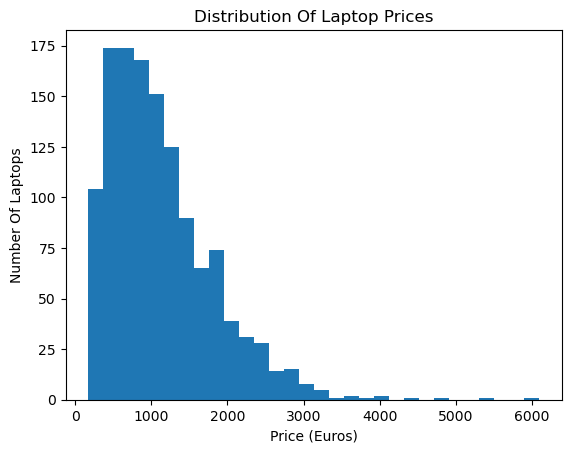

In [14]:
#Price Distribution

import matplotlib.pyplot as plt

plt.hist(df['price_euros'], bins = 30)
plt.title("Distribution Of Laptop Prices")
plt.xlabel("Price (Euros)")
plt.ylabel("Number Of Laptops")
plt.show()

## Insight:
Most laptops fall within the mid-range price segment, indicating a competitive market focused on affordability with balanced performance.

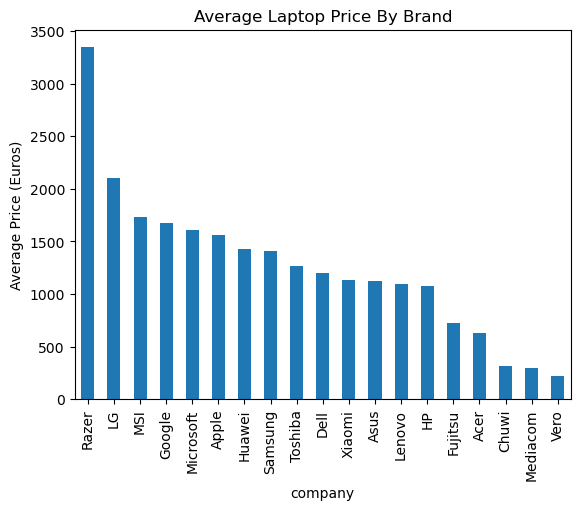

In [15]:
#Average Price By Brand

brand_price = df.groupby('company')['price_euros'].mean().sort_values(ascending=False)

brand_price.plot(kind='bar')
plt.title("Average Laptop Price By Brand")
plt.ylabel("Average Price (Euros)")
plt.show()

## Insight:
Premium brands such as Apple command significantly higher average prices, reinforcing strong brand-driven pricing strategies.

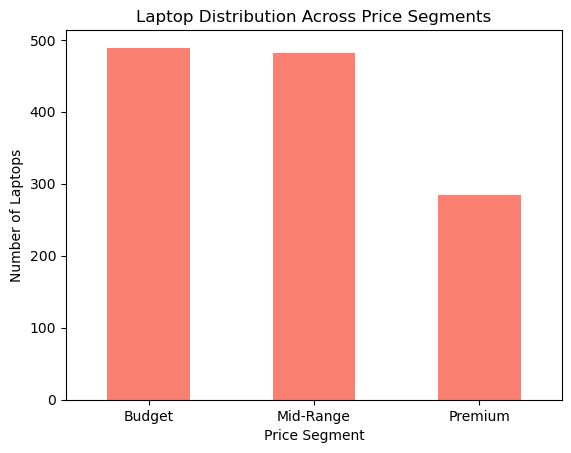

In [16]:
#Price Distribution by Segment

segment_counts = df['price_category'].value_counts().sort_index()

segment_counts.plot(kind='bar', color='salmon')
plt.title("Laptop Distribution Across Price Segments")
plt.xlabel("Price Segment")
plt.ylabel("Number of Laptops")
plt.xticks(rotation=0)
plt.show()

## Insight:
The majority of laptops fall in the Budget and Mid-Range segment, indicating a highly competitive market where pricing and feature optimization are critical.

In [17]:
budget_laptop = df[df["price_category"] == 'Budget']
budget_laptop.head(2)

,company,product,typename,inches,ram,os,weight,price_euros,screen,screenw,...,cpu_company,cpu_freq,cpu_model,primarystorage,secondarystorage,primarystoragetype,secondarystoragetype,gpu_company,gpu_model,price_category
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.0,Full HD,1920,...,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620,Budget
5,Acer,Aspire 3,Notebook,15.6,4,Windows 10,2.10,400.0,Standard,1366,...,AMD,3.0,A9-Series 9420,500,0,HDD,No,AMD,Radeon R5,Budget


In [18]:
#Total Storage
df['total_storage'] = df['primarystorage'] + df['secondarystorage']


In [19]:
#Storage type SSD vs Non-SSD

df['has_ssd'] = df['primarystoragetype'].str.contains('SSD', case=False).astype(int)
df.head(3)

,company,product,typename,inches,ram,os,weight,price_euros,screen,screenw,...,cpu_model,primarystorage,secondarystorage,primarystoragetype,secondarystoragetype,gpu_company,gpu_model,price_category,total_storage,has_ssd
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640,Mid-Range,128,1
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000,Mid-Range,128,0
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620,Budget,256,1


C:\Users\GOURAB PC\AppData\Local\Temp\ipykernel_12020\3031069706.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['price_category', 'has_ssd'])['price_euros']


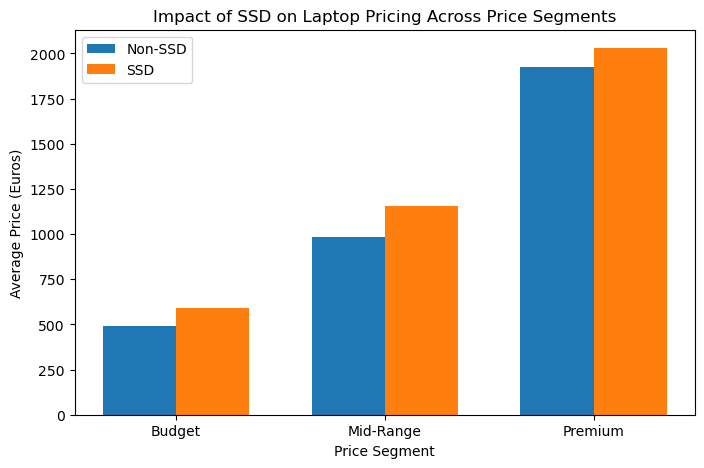

In [20]:
#Average Laptop Price by Price Segment & SSD Presence

grouped = (
    df.groupby(['price_category', 'has_ssd'])['price_euros']
    .mean()
    .unstack()
)

# Bar positions
x = np.arange(len(grouped.index))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, grouped[0], width, label='Non-SSD')
plt.bar(x + width/2, grouped[1], width, label='SSD')

plt.xlabel("Price Segment")
plt.ylabel("Average Price (Euros)")
plt.title("Impact of SSD on Laptop Pricing Across Price Segments")
plt.xticks(x, grouped.index)
plt.legend()
plt.show()


## Insight:
   This chart clearly shows that SSD-equipped laptops consistently command higher prices across all market segments.

   The price gap between SSD and non-SSD devices widens significantly in the mid-range and premium segments, highlighting storage technology as a critical driver of perceived value and pricing strategy.

In [21]:
#High Performance Laptops

df['high_ram'] = (df['ram'] >=16).astype(int)

In [22]:
#CPU brand category

df['cpu_brand'] = df['cpu_company'].replace({
    'Intel' : 'Intel',
    'AMD' : 'AMD',
    'Samsung' : 'Samsung',
    'ARM' : 'Other'
})

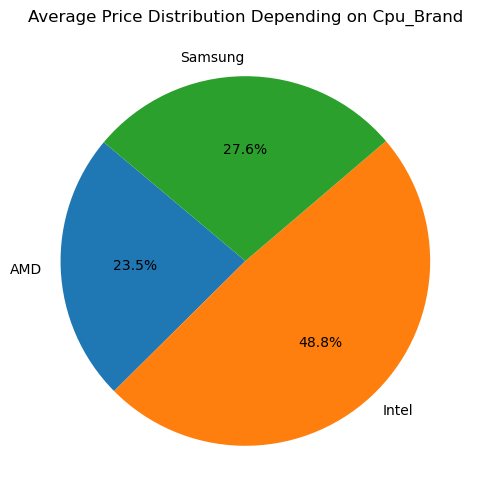

In [23]:
#Price Distribution Depending on Cpu_Brand

cpu_brand_prices = df.groupby('cpu_brand')['price_euros'].mean()

cpu_brand_prices.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    startangle=140
)
plt.title("Average Price Distribution Depending on Cpu_Brand")
plt.ylabel("")
plt.show()

## Insight:
Intel has the highest share according to the chart, this indicates that customers prefer to buy laptops equipped with Intel CPUs.

In [24]:
#is the laptop lightweight OR not 

df['is_lightweight'] = (df['weight'] <= 1.8).astype(int)

In [25]:
#Laptops with high resolution

df['high_resolution'] = (df['screenw'] >=1920).astype(int)

In [26]:
#Example Trend Analysis

df.groupby('price_category')['has_ssd'].mean()*100

#Insights -- Premimum Laptops almost universally includes SSDs, while Budget laptops shows mixed storage configurations.

C:\Users\GOURAB PC\AppData\Local\Temp\ipykernel_12020\231122745.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_category')['has_ssd'].mean()*100


price_category
Budget       32.310838
Mid-Range    80.705394
Premium      95.087719
Name: has_ssd, dtype: float64

In [27]:
#Calculation of Price per GB of RAM

df['price_per_gb_ram'] = df['price_euros'] / df['ram']

#Insights -- shows value for money, not just the Price.

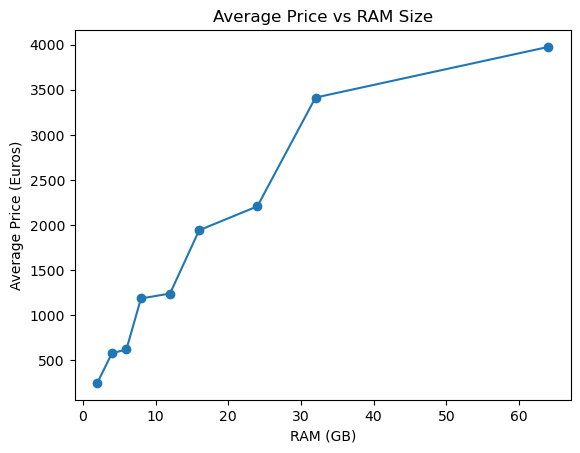

In [28]:
#RAM vs Price

df.groupby('ram')['price_euros'].mean().plot(kind='line',marker='o')
plt.title("Average Price vs RAM Size")
plt.xlabel("RAM (GB)")
plt.ylabel("Average Price (Euros)")
plt.show()

## Insight:
   Laptop prices increase significantly with higher RAM configurations, highlighting RAM as a key price driver.

## Key Business Insights:-

1. The laptop market is heavily concentrated in the mid-range segment, indicating intense competition where small specification improvements can significantly influence pricing.

2. Across all price segments, laptops with SSD storage consistently command higher prices, highlighting storage technology as a critical factor in perceived product value.

3. Laptop prices increase sharply beyond 16GB RAM configurations, demonstrating that higher performance tiers are priced at a premium rather than linearly.

4. Premium brands, particularly Apple, maintain substantially higher average prices compared to competitors, reflecting strong brand equity and ecosystem-driven pricing.

5. Lightweight laptops tend to be priced higher, indicating growing consumer demand for portability and premium build quality.

In [29]:
#save the dataset

df.to_csv("Cleaned_Laptop_Prices_Analysis.csv", index=False)